In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [5]:
df = pd.read_csv(r"C:\Users\saptu\Downloads\50_Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [7]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [9]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

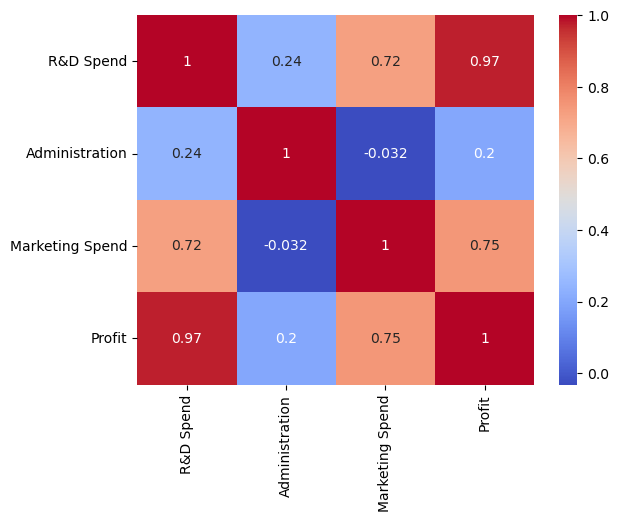

In [10]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='coolwarm')
plt.show()

In [11]:
#Feature and target separation 
#1) target(y)=Profit
#2) Features(X)= all other cols 
X=df.drop('Profit',axis=1)
y=df['Profit']

Encoding Categorical Variable(State)

We use One Hot Encoding because state is a nominal categorical feature 


In [13]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0


#### Train- Test split 

In [14]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y ,test_size=0.2, random_state=42
)

#### Feature Scaling

Scaling is important because features have different units and ranges 

In [16]:
from sklearn.preprocessing import StandardScaler 

scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Model Training- MLR

In [17]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

#### Model Coefficients

Each coefficient shows how much the profit changes with a unit change in the feature.

In [18]:
coeff_df = pd.DataFrame({
    'feature' : X_encoded.columns,
    'Coefficient' : model.coef_
})
coeff_df

,feature,Coefficient
0,R&D Spend,38102.269270
1,Administration,-1864.754300
2,Marketing Spend,3386.175807
3,State_Florida,447.775725
4,State_New York,3.272891


#### Predictions

In [19]:
y_pred = model.predict(X_test_scaled)

comparison = pd.DataFrame({
    'Actual Profit' : y_test.values,
    'Predicted Profit' : y_pred
})
comparison 

,Actual Profit,Predicted Profit
0,134307.35,126362.879083
1,81005.76,84608.453836
2,99937.59,99677.494252
3,64926.08,46357.460686
4,125370.37,128750.482885
5,35673.41,50912.417419
6,105733.54,109741.350327
7,107404.34,100643.242816
8,97427.84,97599.275746
9,122776.86,113097.425244


### Predicting Profit for a New Startup 

In [21]:
new_startup = pd.DataFrame([{
    'R&D Spend' : 160000,
    'Administration' : 120000,
    'Marketing Spend' : 300000,
    'State_Florida' : 0,
    'State_New York' : 1
}])
new_startup_scaled = scaler.transform(new_startup)
model.predict(new_startup_scaled)

array([183637.9245517])

### Model Evaluation (Regression Metrices)


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(6961.477813275555, 9055.957323497796, 0.898726641431984)

### Final Notes

-Multiple Linear Regression predicts continuous values   
-ENcoding and scaling are essential steps here   
-Evaluation is based on error metrics, not accuracy    
-This dataset clearly shows how multiple factors influence profit  